In [ ]:
import pandas as pd

In [ ]:
small_kmp = pd.read_csv("out/kmp/resultados_SmallGenerated.csv")
medium_kmp = pd.read_csv("out/kmp/resultados_MediumGenerated.csv")
large_kmp = pd.read_csv("out/kmp/resultados_LargeGenerated.csv")
verylarge_kmp = pd.read_csv("out/kmp/resultados_VeryLargeGenerated.csv")
small_forcaBruta = pd.read_csv("out/forcaBruta/resultados_SmallGenerated.csv")
medium_forcaBruta = pd.read_csv("out/forcaBruta/resultados_MediumGenerated.csv")
large_forcaBruta = pd.read_csv("out/forcaBruta/resultados_LargeGenerated.csv")
verylarge_forcaBruta = pd.read_csv("out/forcaBruta/resultados_VeryLargeGenerated.csv")

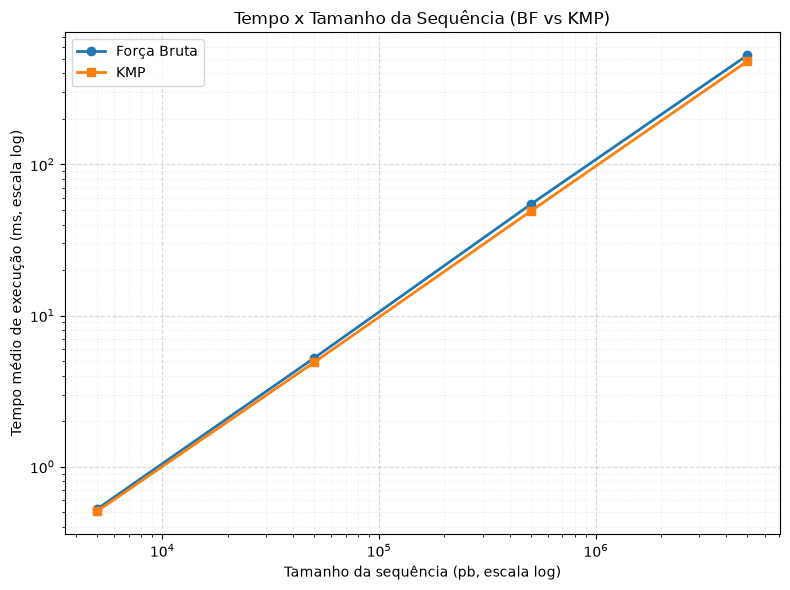

In [5]:
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator

# Tamanho das sequências
N = [
    small_forcaBruta["Tamanho Texto (N)"].iloc[0],
    medium_forcaBruta["Tamanho Texto (N)"].iloc[0],
    large_forcaBruta["Tamanho Texto (N)"].iloc[0],
    verylarge_forcaBruta["Tamanho Texto (N)"].iloc[0]
]

# Tempo médio considerando todos os padrões
tempo_fb = [
    small_forcaBruta["Tempo (ms)"].mean(),
    medium_forcaBruta["Tempo (ms)"].mean(),
    large_forcaBruta["Tempo (ms)"].mean(),
    verylarge_forcaBruta["Tempo (ms)"].mean()
]

tempo_kmp = [
    small_kmp["Tempo (ms)"].mean(),
    medium_kmp["Tempo (ms)"].mean(),
    large_kmp["Tempo (ms)"].mean(),
    verylarge_kmp["Tempo (ms)"].mean()
]


plt.figure(figsize=(8,6))


plt.plot(
    N,
    tempo_fb,
    marker="o",
    linewidth=2,
    label="Força Bruta"
)

plt.plot(
    N,
    tempo_kmp,
    marker="s",
    linewidth=2,
    label="KMP"
)


# Escala logarítmica
plt.xscale("log")
plt.yscale("log")


plt.xlabel("Tamanho da sequência (pb, escala log)")
plt.ylabel("Tempo médio de execução (ms, escala log)")

plt.title("Tempo x Tamanho da Sequência (BF vs KMP)")


# Configuração da grade
ax = plt.gca()

ax.xaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_major_locator(LogLocator(base=10))

ax.xaxis.set_minor_locator(
    LogLocator(base=10, subs=[2,3,4,5,6,7,8,9])
)

ax.yaxis.set_minor_locator(
    LogLocator(base=10, subs=[2,3,4,5,6,7,8,9])
)


plt.grid(
    True,
    which="major",
    linestyle="--",
    alpha=0.5
)

plt.grid(
    True,
    which="minor",
    linestyle=":",
    alpha=0.25
)


plt.legend()

plt.tight_layout()

plt.show()

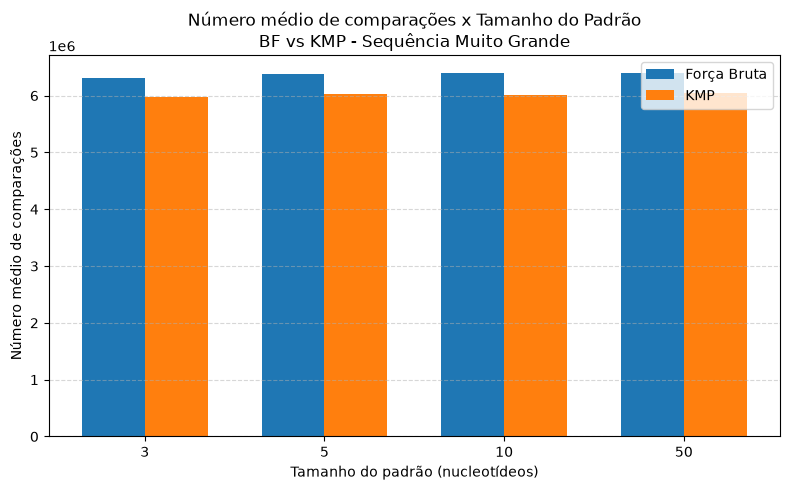

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Sequência Muito Grande (N fixo)
fb = verylarge_forcaBruta
kmp = verylarge_kmp


# Tamanhos de padrão (M)
M = sorted(
    fb["Tamanho Padrão (M)"].unique()
)


# Média das comparações para cada M
comp_fb = [
    fb[fb["Tamanho Padrão (M)"] == m]["Nº Comparações"].mean()
    for m in M
]

comp_kmp = [
    kmp[kmp["Tamanho Padrão (M)"] == m]["Nº Comparações"].mean()
    for m in M
]


# Posição das barras
x = np.arange(len(M))
largura = 0.35


plt.figure(figsize=(8,5))


plt.bar(
    x - largura/2,
    comp_fb,
    width=largura,
    label="Força Bruta"
)

plt.bar(
    x + largura/2,
    comp_kmp,
    width=largura,
    label="KMP"
)


plt.xticks(
    x,
    M
)


plt.xlabel("Tamanho do padrão (nucleotídeos)")
plt.ylabel("Número médio de comparações")

plt.title(
    "Número médio de comparações x Tamanho do Padrão\n"
    "BF vs KMP - Sequência Muito Grande"
)


plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)


plt.legend()

plt.tight_layout()

plt.show()

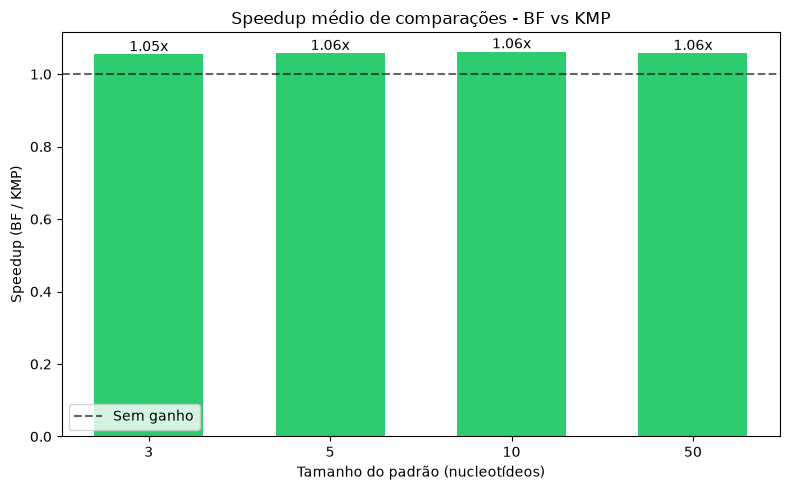

In [11]:
import matplotlib.pyplot as plt
import numpy as np

bases_fb = [
    small_forcaBruta,
    medium_forcaBruta,
    large_forcaBruta,
    verylarge_forcaBruta
]

bases_kmp = [
    small_kmp,
    medium_kmp,
    large_kmp,
    verylarge_kmp
]

M = sorted(small_forcaBruta["Tamanho Padrão (M)"].unique())

comp_fb = []
comp_kmp = []

for m in M:
    comparacoes_fb = []
    comparacoes_kmp = []

    for fb, kmp in zip(bases_fb, bases_kmp):
        comparacoes_fb.extend(fb[fb["Tamanho Padrão (M)"] == m]["Nº Comparações"])
        comparacoes_kmp.extend(kmp[kmp["Tamanho Padrão (M)"] == m]["Nº Comparações"])

    comp_fb.append(np.mean(comparacoes_fb))
    comp_kmp.append(np.mean(comparacoes_kmp))

speedup = [bf / kmp for bf, kmp in zip(comp_fb, comp_kmp)]

# Gráfico
x = np.arange(len(M))

plt.figure(figsize=(8, 5))
bars = plt.bar(x, speedup, width=0.6, color="#2ecc71")

plt.axhline(y=1, linestyle="--", color="black", alpha=0.6, label="Sem ganho")

plt.xticks(x, M)
plt.xlabel("Tamanho do padrão (nucleotídeos)")
plt.ylabel("Speedup (BF / KMP)")
plt.title("Speedup médio de comparações - BF vs KMP")

for bar, val in zip(bars, speedup):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.2f}x",
              ha="center", va="bottom")

plt.legend()
plt.tight_layout()
plt.show()